***Iris Dataset***

In [1]:
#iris dataset
# Import required libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix


from google.colab import files
uploaded = files.upload()





Saving iris (1).csv to iris (1).csv


In [2]:
# Load dataset
data = pd.read_csv("iris (1).csv")

# Features and target
X = data.drop("species", axis=1)   # independent variables
y = data["species"]                # target variable

# Split dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------- Linear Kernel SVM -----------
svm_linear = SVC(kernel='linear')

# Train model
svm_linear.fit(X_train, y_train)

# Prediction
y_pred_linear = svm_linear.predict(X_test)

# Evaluation
print("Linear Kernel Results")
print("Accuracy:", accuracy_score(y_test, y_pred_linear))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_linear))


# ----------- RBF Kernel SVM -----------
svm_rbf = SVC(kernel='rbf')

# Train model
svm_rbf.fit(X_train, y_train)

# Prediction
y_pred_rbf = svm_rbf.predict(X_test)

# Evaluation
print("\nRBF Kernel Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rbf))

Linear Kernel Results
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

RBF Kernel Results
Accuracy: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [3]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier


from google.colab import files
uploaded = files.upload()

Saving letter-recognition.xlsx to letter-recognition.xlsx


Accuracy: 0.7375
Confusion Matrix:
[[149   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [ 49 104   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [ 30   0 103   0   0   0   1   0   0   0   2   0   0   0   1   0   0   0
    0   0   0   0   0   0   0   0]
 [ 43   0   0 113   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [ 90   0   0   0  51   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [ 42   0   0   0   0  97   0   0   0   0   0   0   0   0   0   0   0   0
    0   1   0   0   0   0   0   0]
 [ 71   0   0   0   0   0  87   0   0   0   0   0   0   0   0   0   0   2
    0   0   0   0   0   0   0   0]
 [105   0   0   2   0   0   0  33   0   0   0   0   0   0   0   0   0   4
    0   0   0   0   0   0   0   0]
 [ 21   0   0   0   0   0   0   0 122   0   0   0   0   0   0   0   0   0
    0   0   0   0  

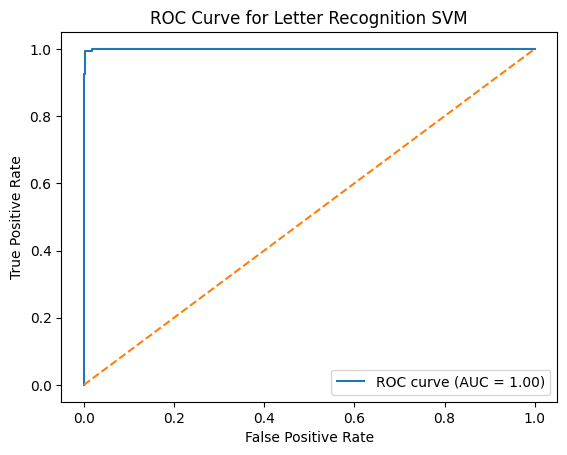

AUC Score for class 0: 0.9996775874478694


In [5]:
# Load dataset
data = pd.read_excel("letter-recognition.xlsx")
# Separate features and target
X = data.drop("letter", axis=1)
y = data["letter"]

# Convert class labels to binary format for ROC
classes = np.unique(y)
y_bin = label_binarize(y, classes=classes)
n_classes = y_bin.shape[1]

# Split dataset (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size=0.2, random_state=42
)

# Train SVM classifier (RBF kernel)
svm_model = OneVsRestClassifier(SVC(kernel='rbf', probability=True))
svm_model.fit(X_train, y_train)

# Prediction
y_pred = svm_model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test.argmax(axis=1), y_pred.argmax(axis=1)))

# ROC and AUC calculation
y_score = svm_model.decision_function(X_test)

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve for first class (example)
plt.figure()
plt.plot(fpr[0], tpr[0], label="ROC curve (AUC = %0.2f)" % roc_auc[0])
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Letter Recognition SVM")
plt.legend()
plt.show()

print("AUC Score for class 0:", roc_auc[0])